In [42]:
import numpy as np
from scipy.stats import invgamma
import matplotlib.pyplot as plt

In [250]:
beta_dim = 10

mu0 = np.zeros(beta_dim)
Gamma0 = np.eye(beta_dim)

a0 = 100
b0 = 1
v0 = a0*2
s02 = b0*2/v0

In [251]:
data_num = 100

true_beta = np.random.random(beta_dim)
true_sigma2 = 0

X = np.random.random([data_num,beta_dim-1])
X = np.hstack([np.ones([data_num,1]), X])
y = X @ true_beta + np.random.normal(size=data_num) * np.sqrt(true_sigma2)

In [252]:
Gamman = X.T @ X + Gamma0
mun = np.linalg.inv(Gamman) @ (Gamma0 @ mu0 + X.T @ y)
an = a0 + data_num/2
bn = b0 + 0.5*(y.T @ y + mu0.T @ Gamma0 @ mu0 - mun.T @ Gamman @ mun)

In [253]:
sigma_test = np.linspace(0,0.5,10000)
pdf_vec = invgamma.pdf(sigma_test,a=an, scale=bn)
pdf_vec_pr = invgamma.pdf(sigma_test,a=a0, scale=b0)

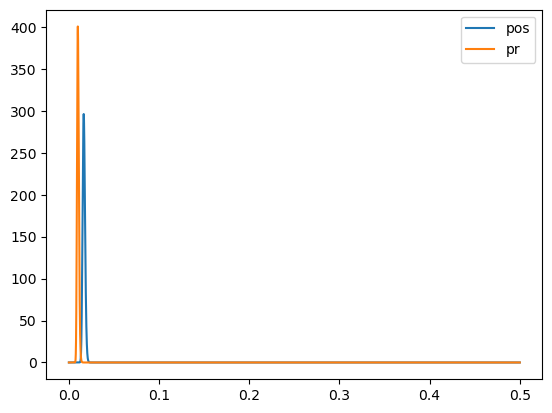

In [254]:
plt.plot(sigma_test,pdf_vec, label="pos")
plt.plot(sigma_test,pdf_vec_pr, label="pr")
plt.legend()

In [219]:
mun

array([0.4346799 , 0.35207056, 0.05009136, 0.45631195, 0.18343715,
       0.42848823, 0.01303454, 0.75643402, 0.35885779, 0.21383642])

In [220]:
true_beta

array([0.43419428, 0.35222293, 0.04988895, 0.45660332, 0.18339559,
       0.42876103, 0.01278483, 0.75710175, 0.35903236, 0.21382768])

In [221]:
bn

1.7441929474553035

In [222]:
an

5100.0

In [223]:
b0

1